In [ ]:
#Group 2
# Prediction of HEPR

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import math

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error


from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression


In [2]:
## Specify the dataset
data = r'C:\Users\Khushboo\Desktop\DATASET.csv'

In [3]:
# Load and clean
df = pd.read_csv(data)
df.columns = df.columns.str.strip().str.lower()

In [4]:
# ENGINEERED FEATURES

#(A) Temperature rise on tube side
df['delta_t'] = df['e03_crude_tube_t_out_degc'] - df['e03_crude_tube_t_in_degc']

#(B) Temperature drop on shell side
df['shell_delta_t'] = df['e03_lightdiesel_shell_t_out_degc'] - df['e03_lightdiesel_shell_t_in_degc']

#(C) Convert operating hours to days
df['time_days'] = df['time_hr'] / 24

#TARGET VARIABLE (OUTPUT) Calculate Q_actual = m * Cp * ΔT (watts)
q_actual = (
    df['e03_crude_tube_m_kg_s'] *
    df['e03_crude_tube_cp_j_kgk'] *
    df['delta_t']
)

# HEPR = ActualDuty / DesignDuty
df['hepr'] = q_actual / df['e03_design_duty_w']

# FINAL FEATURE LIST (INPUT = X, TARGET = y)
X = df[
    [
        'crude_api',
        'crude_chlorides',
        'crude_tan',
        'time_hr',
        'time_days',
        'e03_crude_tube_t_in_degc',
        'e03_crude_tube_t_out_degc',
        'e03_crude_tube_m_kg_s',
        'e03_crude_tube_cp_j_kgk',
        'e03_lightdiesel_shell_t_in_degc',
        'e03_lightdiesel_shell_t_out_degc',
        'e03_lightdiesel_shell_m_kg_s',
        'delta_t',
        'shell_delta_t'
    ]
]

y = df['hepr']

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (6400, 14)
Final y shape: (6400,)


In [5]:
# SUMMARY STATISTICS
df.describe()

,row number,crude_api,crude_chlorides,crude_tan,time_hr,e01_crude_tube_cp_j_kgk,e01_crude_tube_t_in_degc,e01_crude_tube_t_out_degc,e01_crude_tube_m_kg_s,e01_design_duty_w,...,e05_crude_tube_m_kg_s,e05_design_duty_w,e05_heavydiesel_shell_cp_j_kgk,e05_heavydiesel_shell_t_in_degc,e05_heavydiesel_shell_t_out_degc,e05_heavydiesel_shell_m_kg_s,delta_t,shell_delta_t,time_days,hepr
count,6400.0,6400.000000,6400.000000,6400.000000,6400.000000,6400.0,6400.000000,6400.000000,6400.000000,6.400000e+03,...,6400.000000,6.400000e+03,6400.0,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000
mean,2.0,32.004367,9.983130,0.802308,31995.000000,2100.0,150.007189,195.035581,100.118347,9.466506e+06,...,100.126423,6.524623e+06,2150.0,369.947312,335.380189,87.924086,36.813372,-41.030202,1333.125000,0.999959
std,0.0,0.299575,1.509369,0.146364,18476.651933,0.0,1.522564,1.660552,3.088093,7.171744e-07,...,3.083225,1.452977e-07,0.0,1.499784,1.587264,3.095540,1.119830,1.801897,769.860497,0.041735
min,2.0,30.966538,4.332211,0.317031,0.000000,2100.0,144.529654,189.486202,87.498592,9.466506e+06,...,87.031360,6.524623e+06,2150.0,363.811694,329.409801,77.221849,32.750967,-48.386989,0.000000,0.853048
25%,2.0,31.805500,8.937199,0.702659,15997.500000,2100.0,148.999938,193.916999,98.038372,9.466506e+06,...,98.046870,6.524623e+06,2150.0,368.925337,334.311376,85.842058,36.058005,-42.230397,666.562500,0.971749
50%,2.0,32.000232,9.965559,0.802914,31995.000000,2100.0,150.024033,195.025890,100.117526,9.466506e+06,...,100.119540,6.524623e+06,2150.0,369.963851,335.387993,87.926302,36.809084,-41.038679,1333.125000,1.000215
75%,2.0,32.208442,11.012655,0.902200,47992.500000,2100.0,151.029663,196.126551,102.256577,9.466506e+06,...,102.242649,6.524623e+06,2150.0,370.945350,336.437760,90.009354,37.558885,-39.798811,1999.687500,1.027878
max,2.0,33.142878,16.394005,1.392870,63990.000000,2100.0,155.240416,201.270285,110.990296,9.466506e+06,...,111.504008,6.524623e+06,2150.0,375.179390,341.662731,98.798655,40.863723,-34.132570,2666.250000,1.163497


In [6]:
# To confirm
print("X columns:", list(X.columns))
print("X shape:", X.shape)
print("y name:", y.name, "| y shape:", y.shape)


X columns: ['crude_api', 'crude_chlorides', 'crude_tan', 'time_hr', 'time_days', 'e03_crude_tube_t_in_degc', 'e03_crude_tube_t_out_degc', 'e03_crude_tube_m_kg_s', 'e03_crude_tube_cp_j_kgk', 'e03_lightdiesel_shell_t_in_degc', 'e03_lightdiesel_shell_t_out_degc', 'e03_lightdiesel_shell_m_kg_s', 'delta_t', 'shell_delta_t']
X shape: (6400, 14)
y name: hepr | y shape: (6400,)


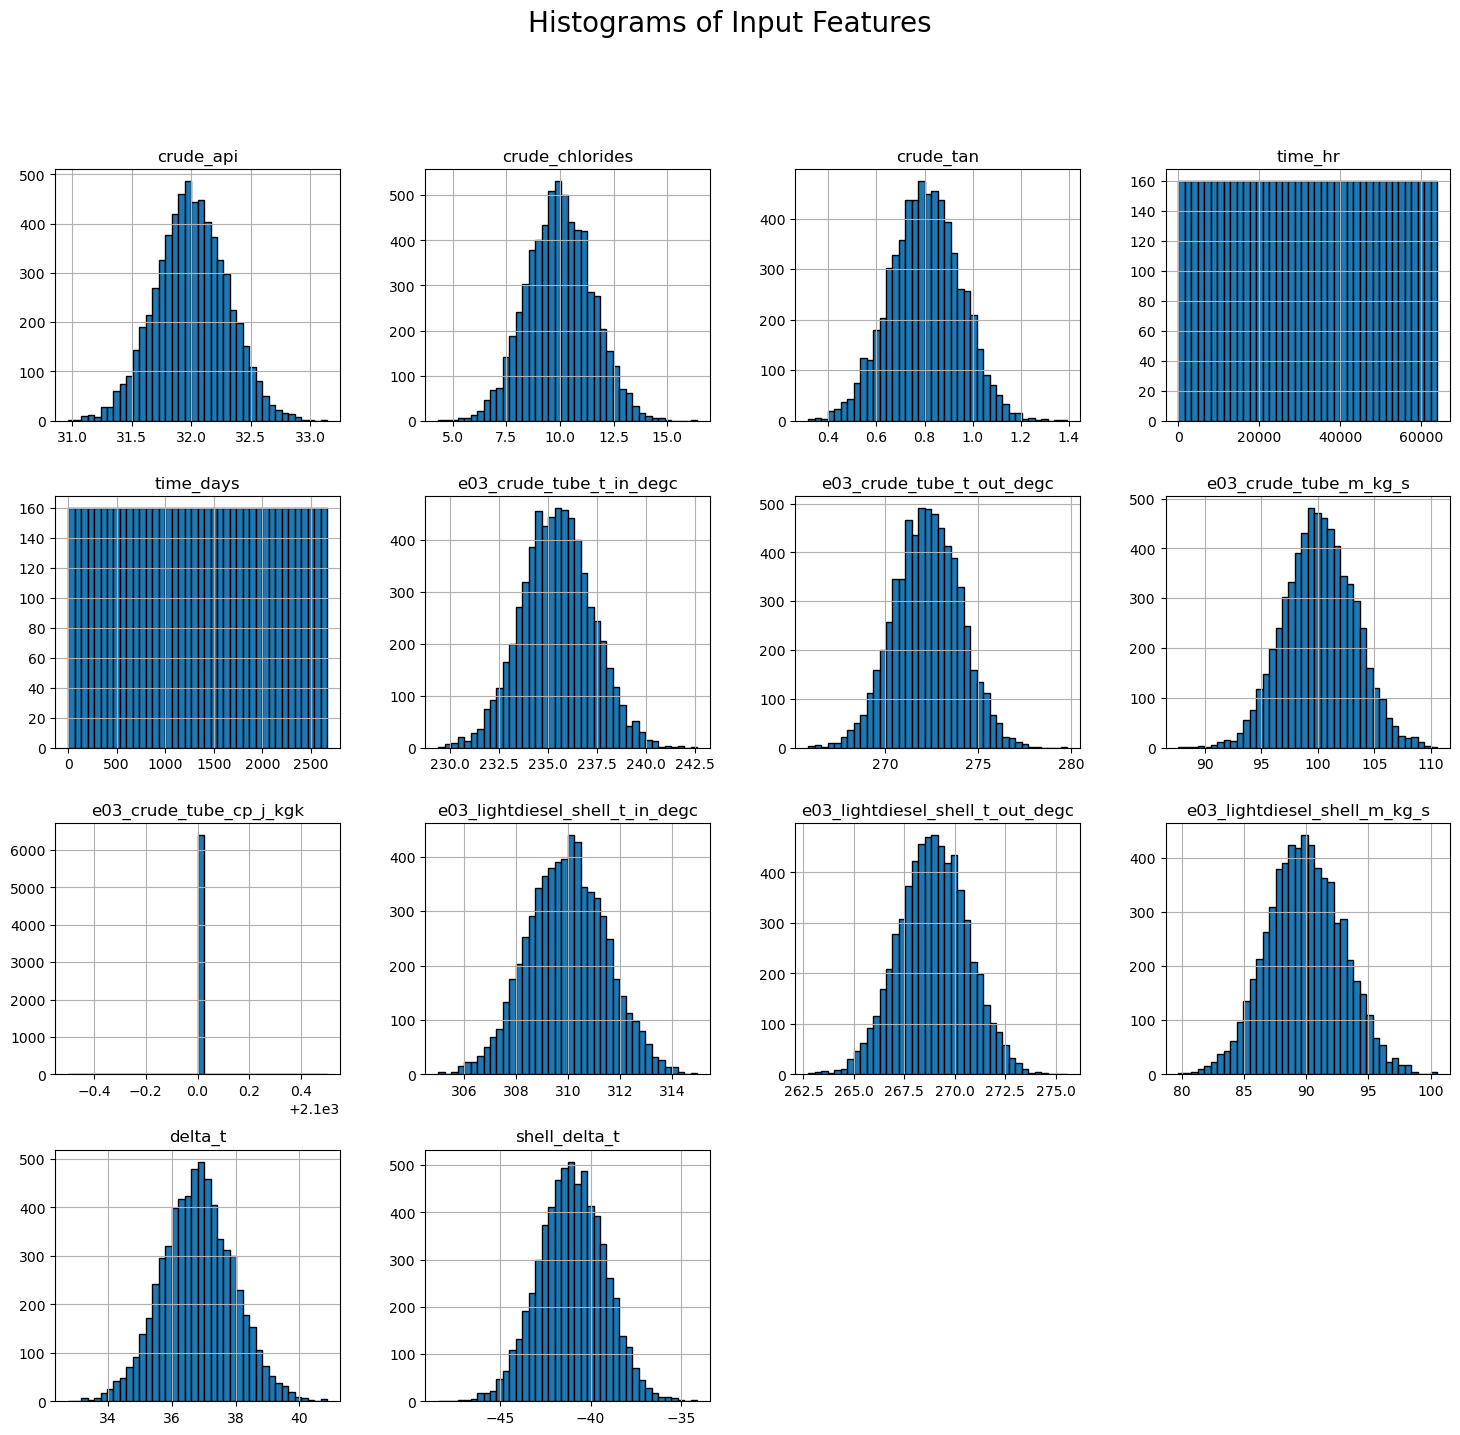

In [7]:
# HISTOGRAMS FOR ALL FEATURES IN X
X.hist(figsize=(18, 16), bins=40, edgecolor='black')
plt.suptitle("Histograms of Input Features", fontsize=20)
plt.show()

C:\Users\Khushboo\AppData\Local\Temp\ipykernel_6228\3732086255.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data, bw_method=bw, color='green', fill=True)


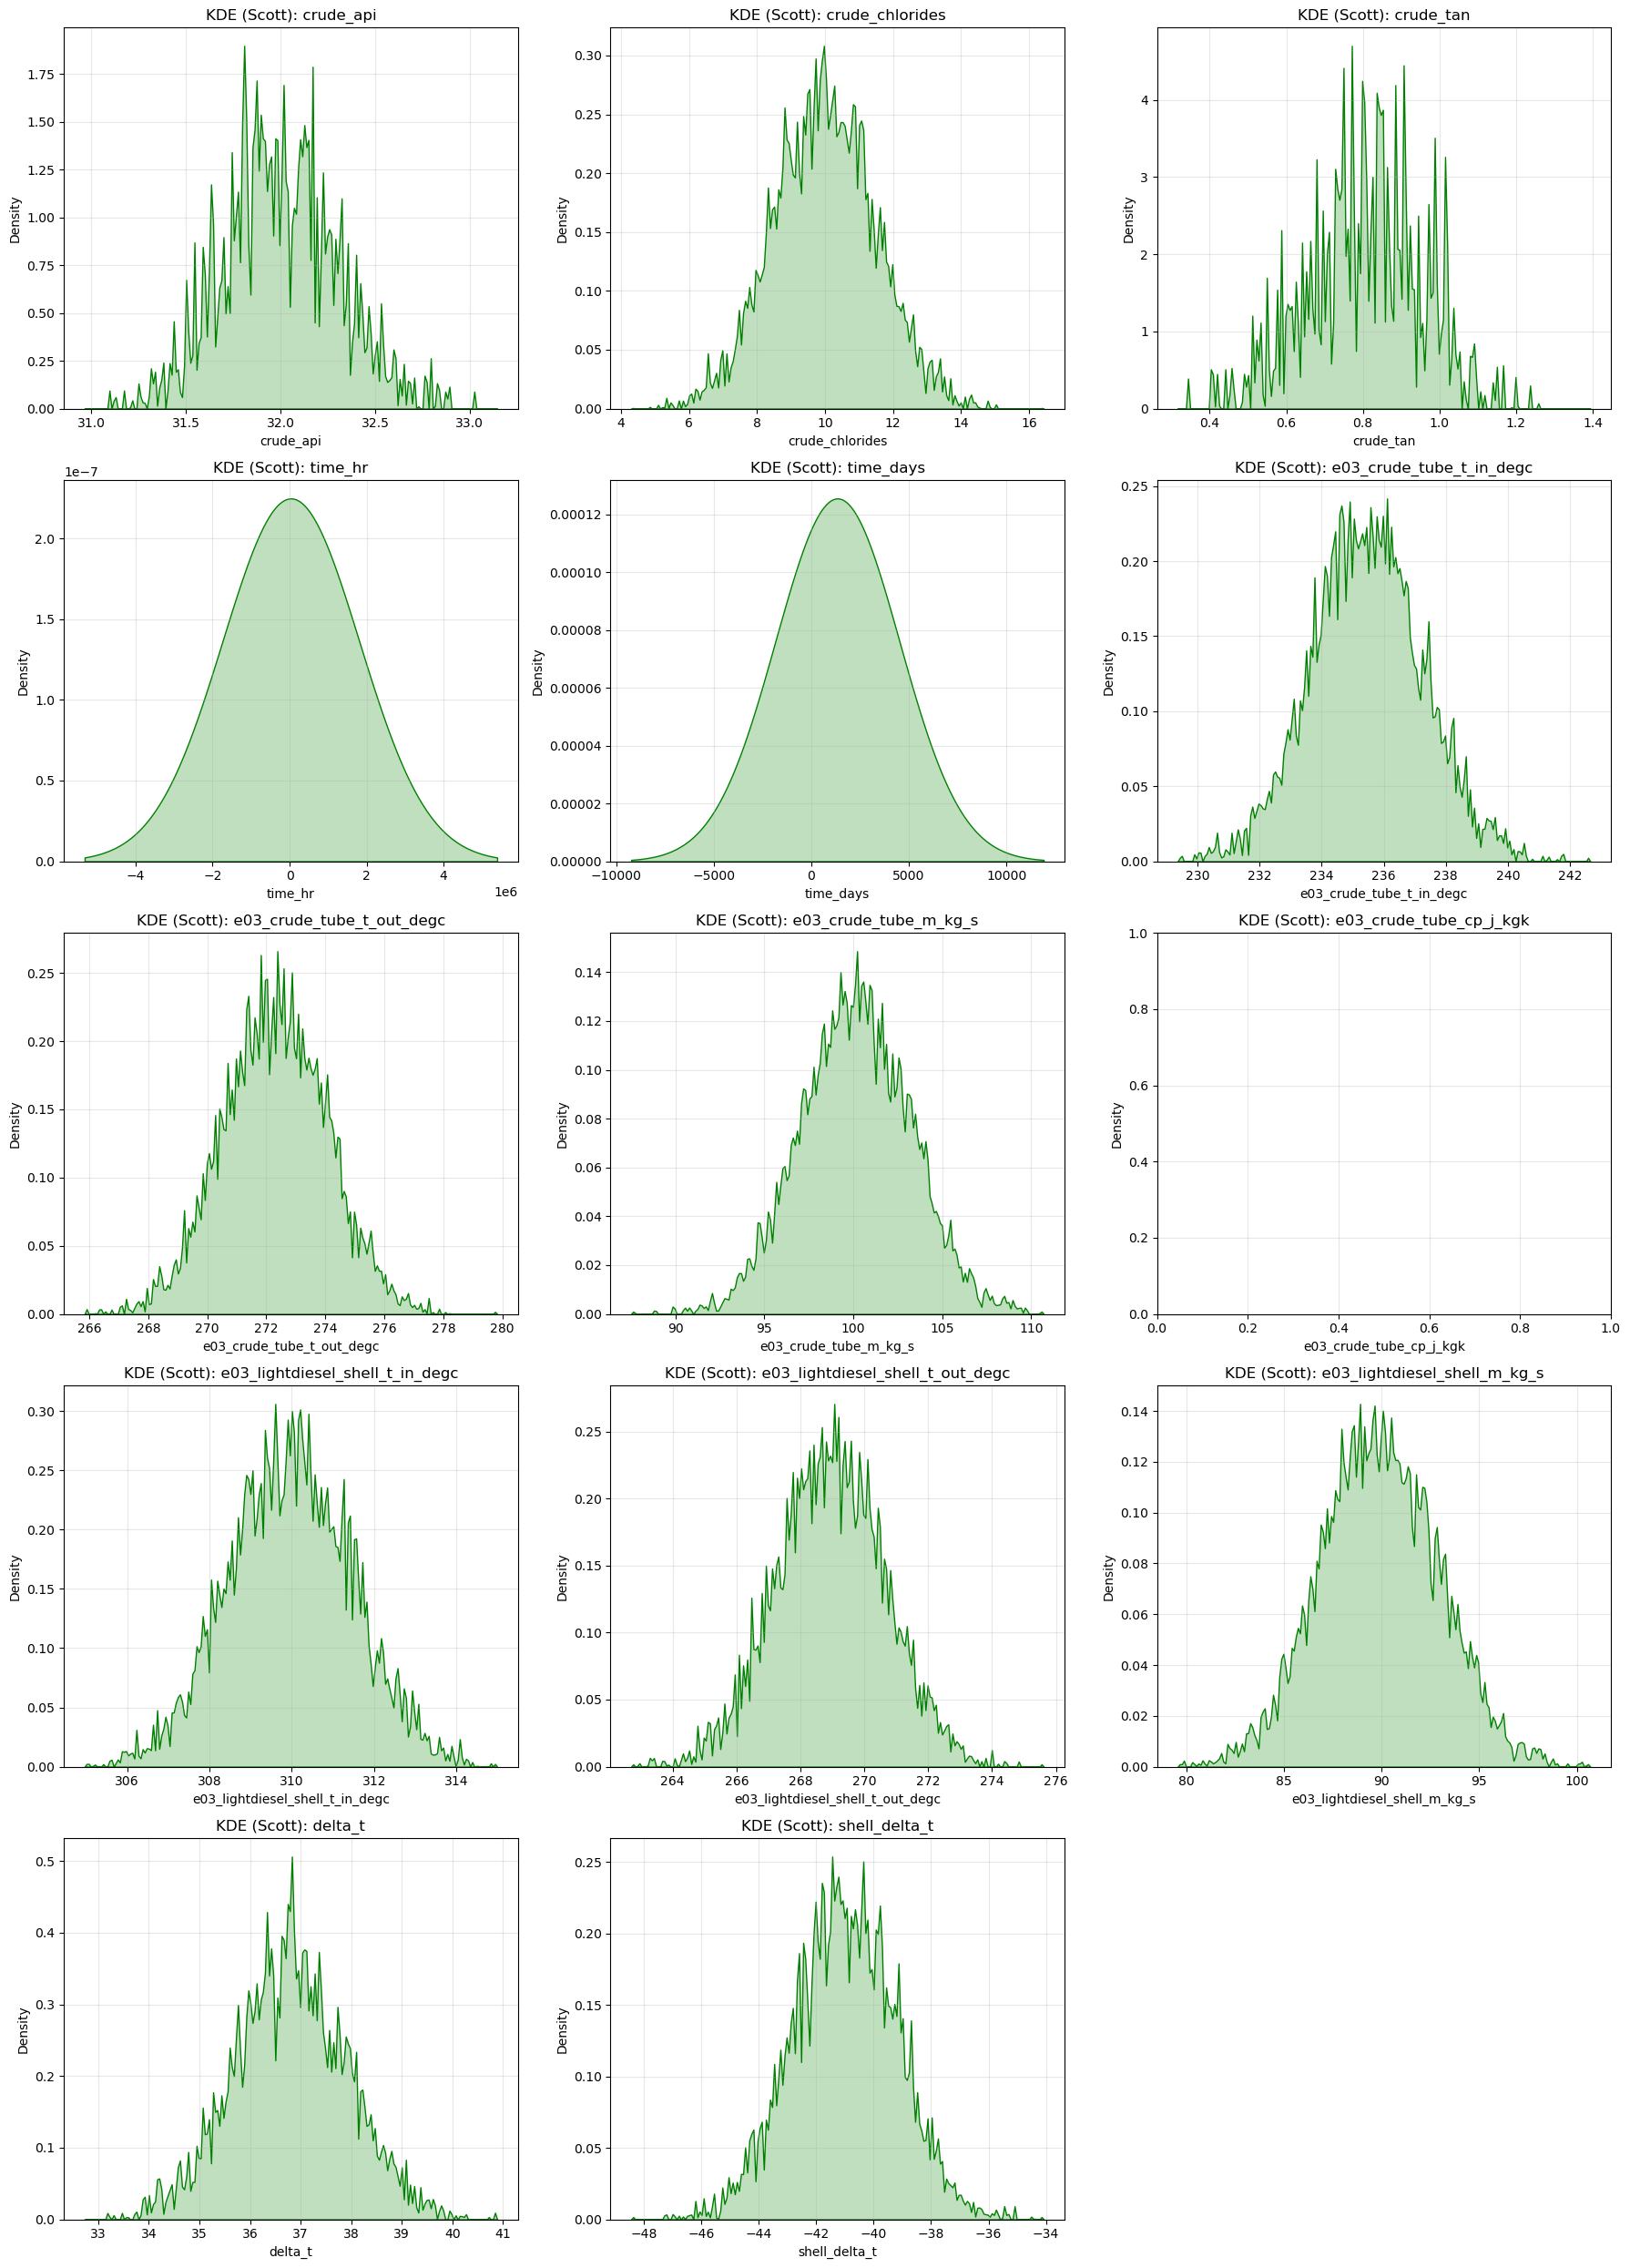

In [8]:
# KDE
kde_features = X.columns 

cols = 3
rows = math.ceil(len(kde_features) / cols)

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(kde_features):
      data = df[col].dropna()
      mu, sigma = norm.fit(data)
      n = len(data)
    
#     # Scott's rule bandwidth
      h_scott = sigma * n ** (-1/5)
      bw = h_scott * 0.03   # multiplier for plot smoothness
    
      plt.subplot(rows, cols, i+1)
      sns.kdeplot(data, bw_method=bw, color='green', fill=True)
      plt.title(f"KDE (Scott): {col}", fontsize=12)
      plt.xlabel(col)
      plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

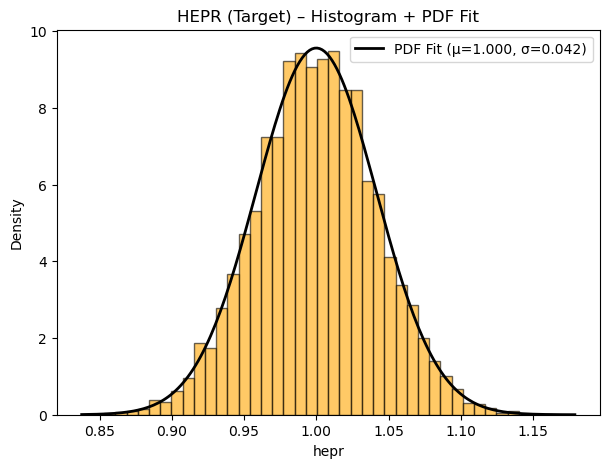

In [9]:
# #Histogram + PDF fit for the target
feature = y.dropna()
mu, sigma = norm.fit(feature)

plt.figure(figsize=(7,5))
plt.hist(feature, bins=40, density=True, alpha=0.6, edgecolor='black', color='orange')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
pdf = norm.pdf(x, mu, sigma)
plt.plot(x, pdf, 'k', linewidth=2, label=f"PDF Fit (μ={mu:.3f}, σ={sigma:.3f})")

plt.title("HEPR (Target) – Histogram + PDF Fit")
plt.xlabel("hepr")
plt.ylabel("Density")
plt.legend()
plt.show()

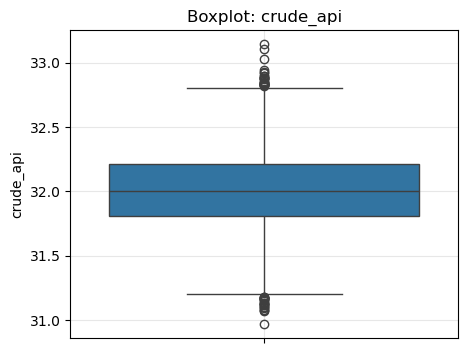

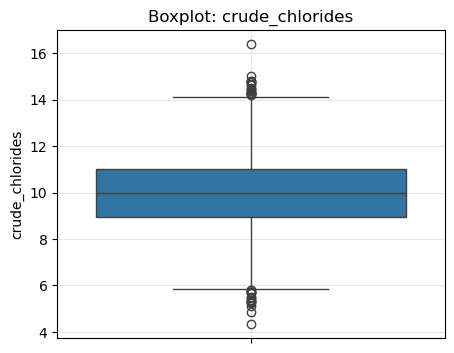

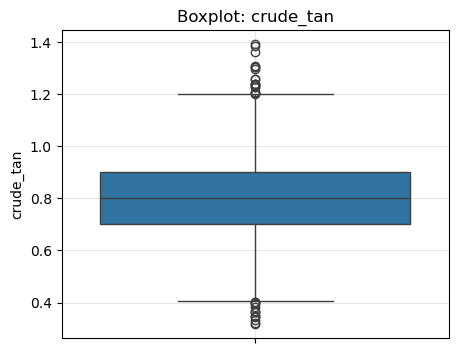

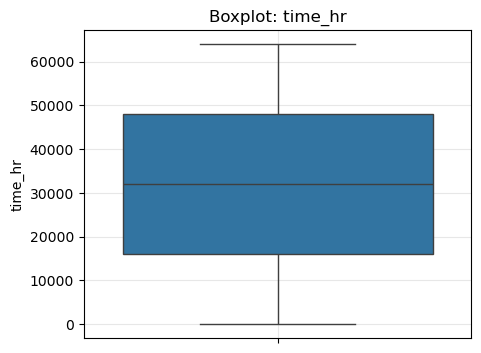

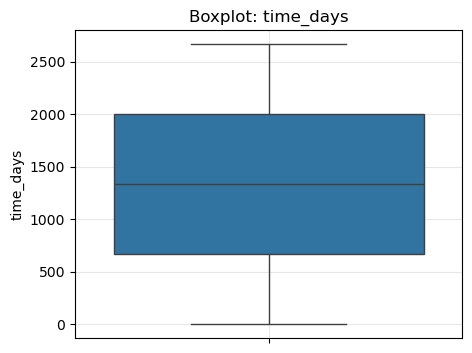

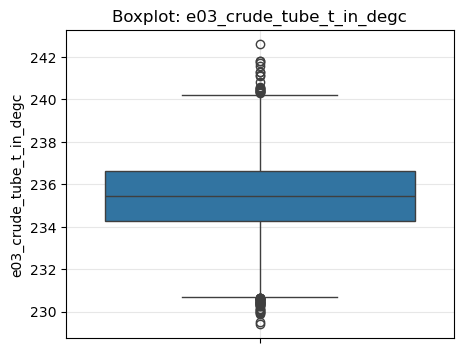

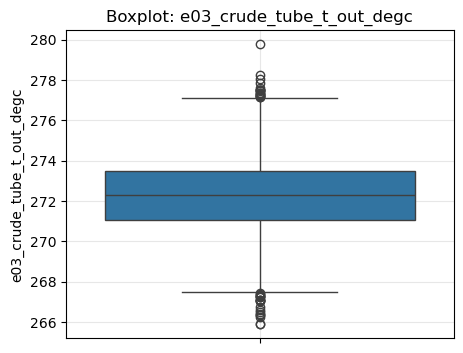

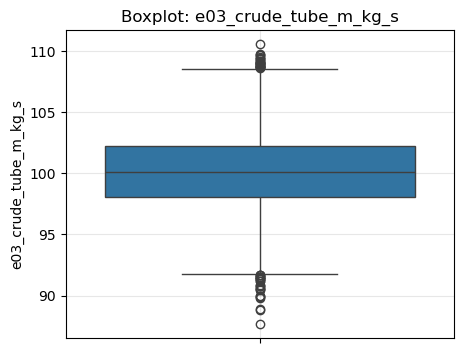

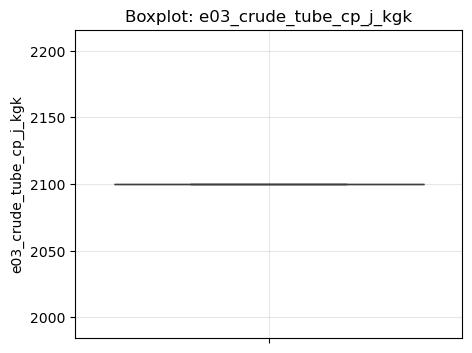

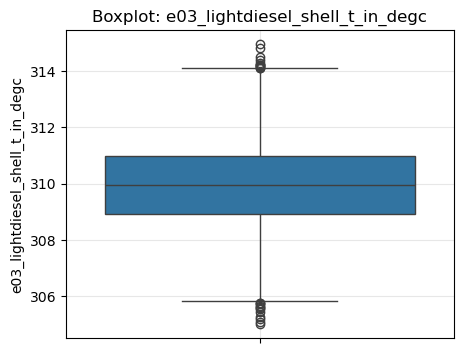

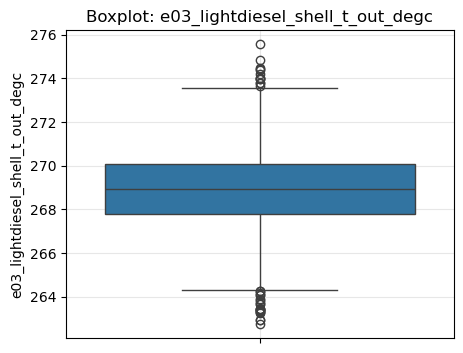

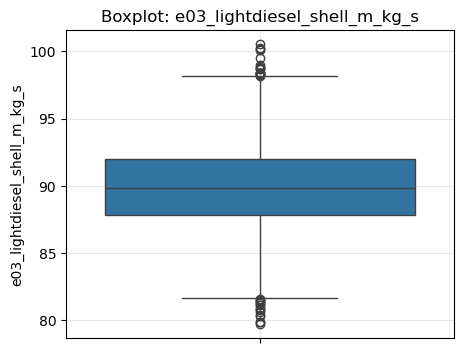

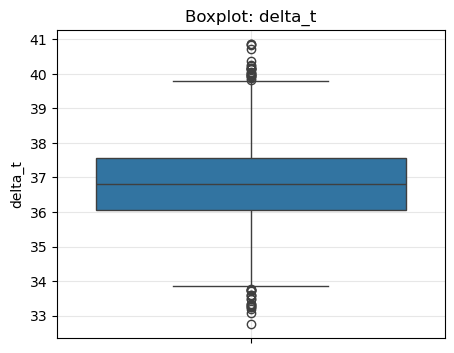

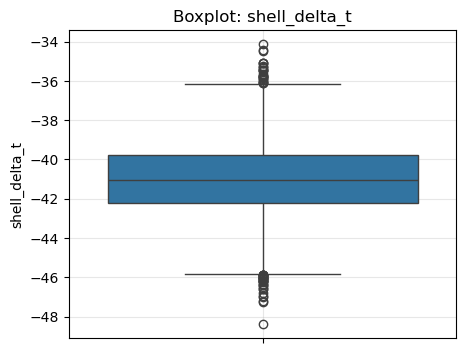

In [10]:
# Boxplots (univariate outlier detection) for all features in X
for col in X.columns:
     plt.figure(figsize=(5,4))
     sns.boxplot(y=X[col])
     plt.title(f"Boxplot: {col}")
     plt.grid(alpha=0.3)
     plt.show()

In [11]:
# outlier values for a specific feature (say delta_t)
col = 'delta_t'

Q1 = np.percentile(X[col], 25)
Q3 = np.percentile(X[col], 75)
IQR = Q3 - Q1

lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR

outliers = X[col][(X[col] < lb) | (X[col] > ub)]
print(f"Outliers in {col}:")
print(outliers)

Outliers in delta_t:
18      39.930978
159     33.720297
185     33.491548
270     32.750967
367     33.742538
440     40.129284
442     40.859819
640     39.879121
688     33.326650
955     39.992574
1089    40.157280
1106    40.263825
1197    33.728564
1544    40.709751
1854    40.237354
2295    40.863723
2537    33.560796
2611    33.184489
2612    33.604863
2665    39.992315
2831    40.157724
2942    33.778587
2992    40.161935
2993    39.821721
3641    33.281368
3671    39.944865
3694    33.233482
3781    33.603640
3841    40.070791
3861    39.927802
3874    39.970284
3940    40.041572
4055    33.754485
4083    33.298409
4364    40.840044
5060    33.466502
5153    40.374293
5168    33.237385
5265    33.078148
5333    33.327919
5762    40.178743
Name: delta_t, dtype: float64


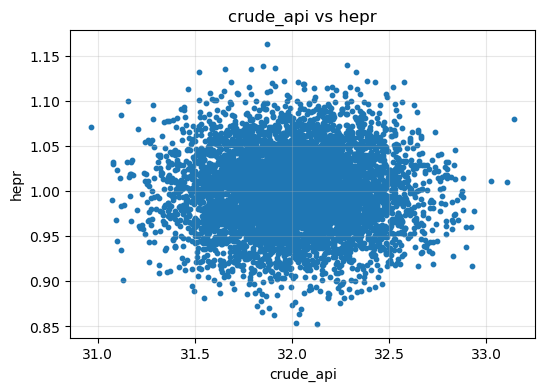

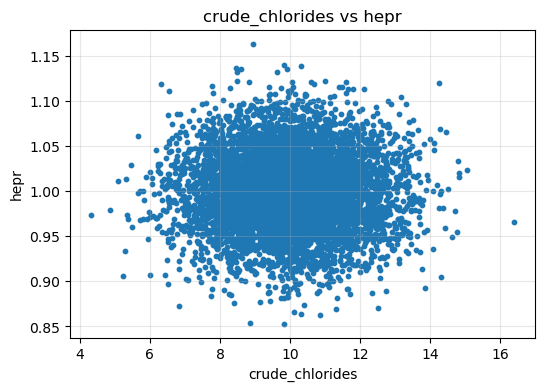

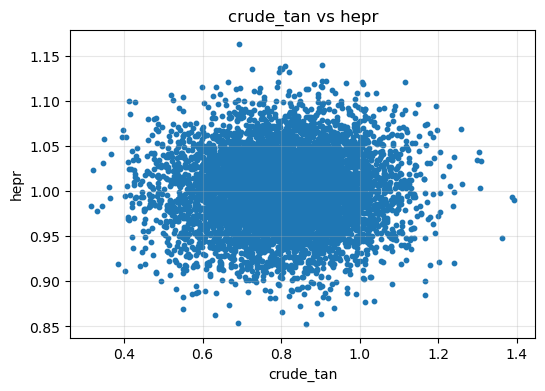

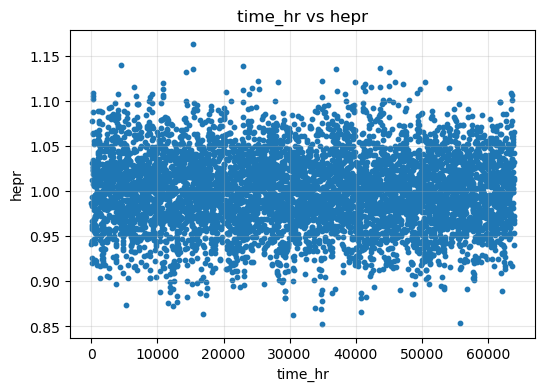

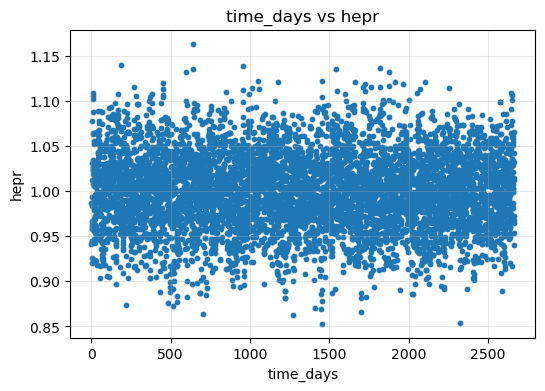

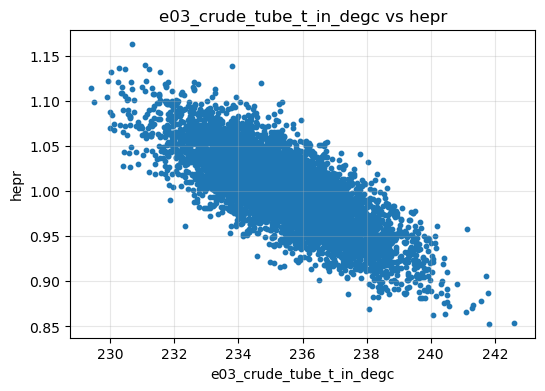

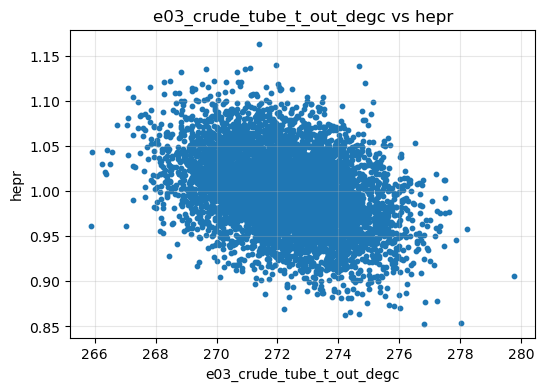

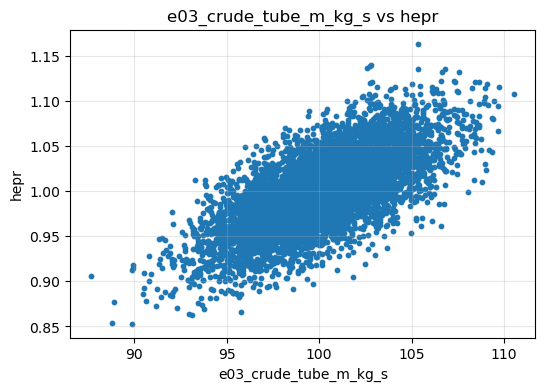

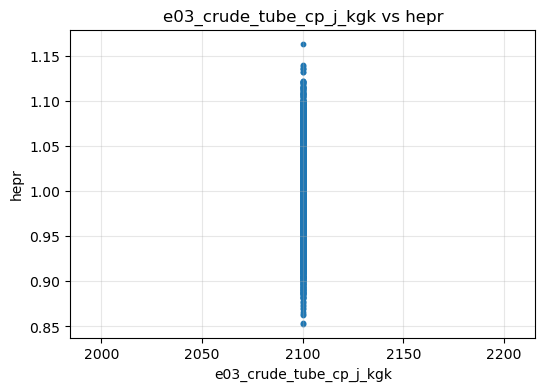

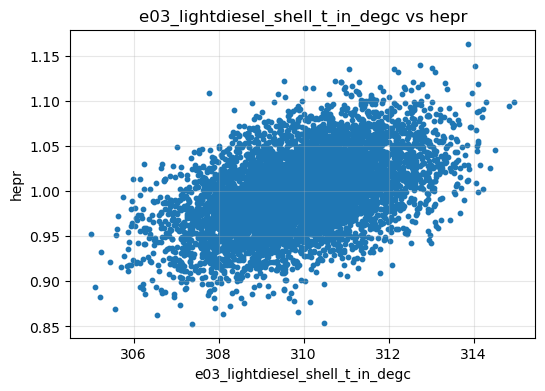

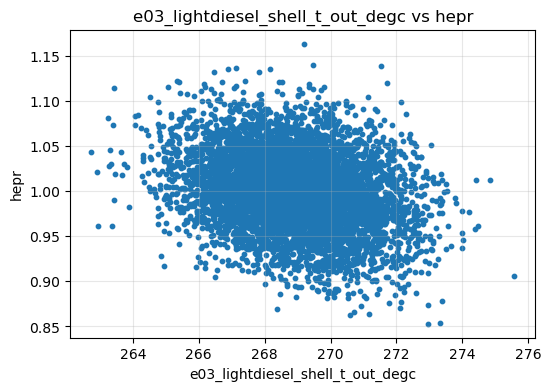

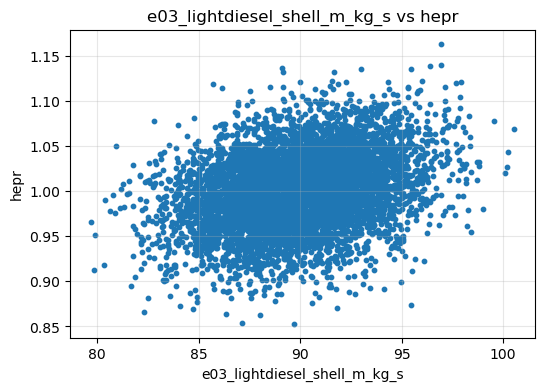

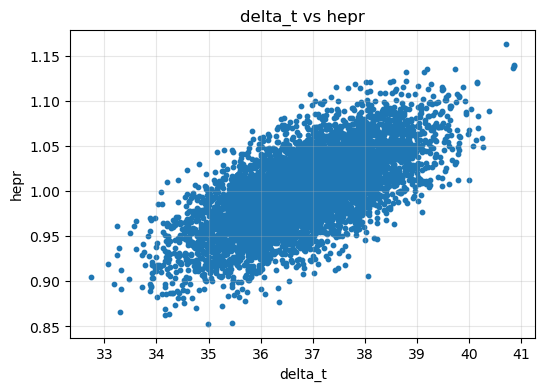

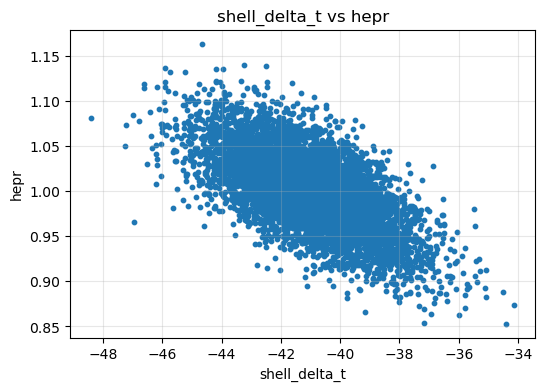

In [12]:
# scatter plots: each feature vs target (hepr)
for col in X.columns:
     plt.figure(figsize=(6,4))
     plt.scatter(X[col], y, s=10)
     plt.xlabel(col)
     plt.ylabel("hepr")
     plt.title(f"{col} vs hepr")
     plt.grid(alpha=0.3)
     plt.show()

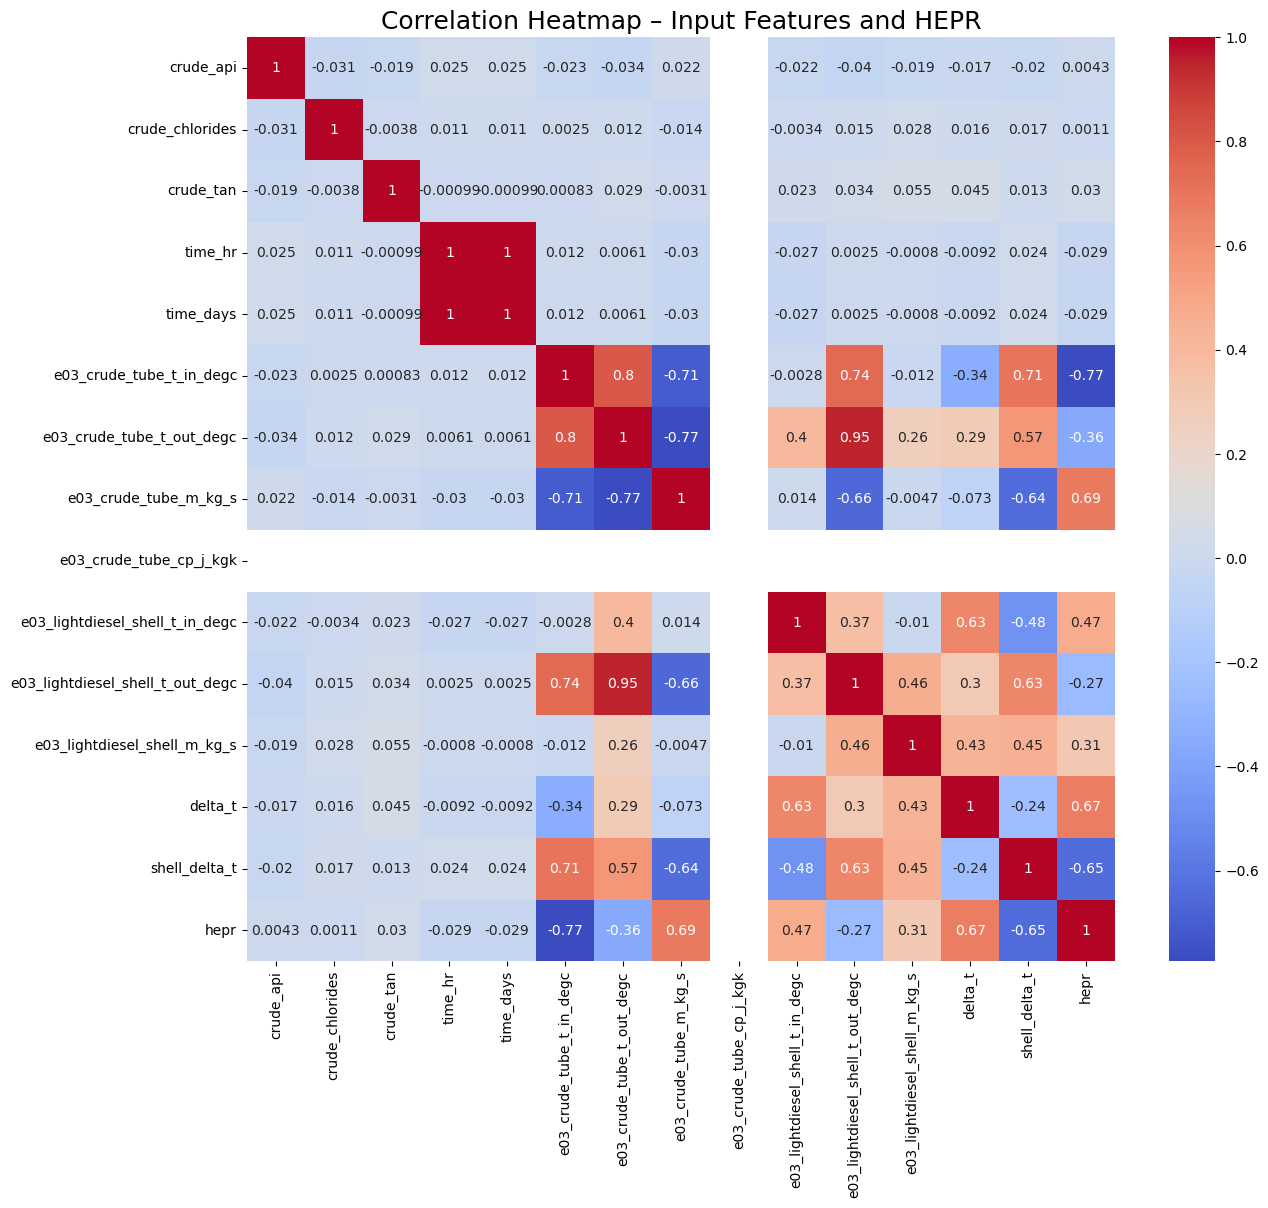

In [13]:
# Correlation matrix using X and y
corr_df = pd.concat([X, y], axis=1)   # combine inputs and target

plt.figure(figsize=(14,12))
sns.heatmap(corr_df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap – Input Features and HEPR", fontsize=18)
plt.show()

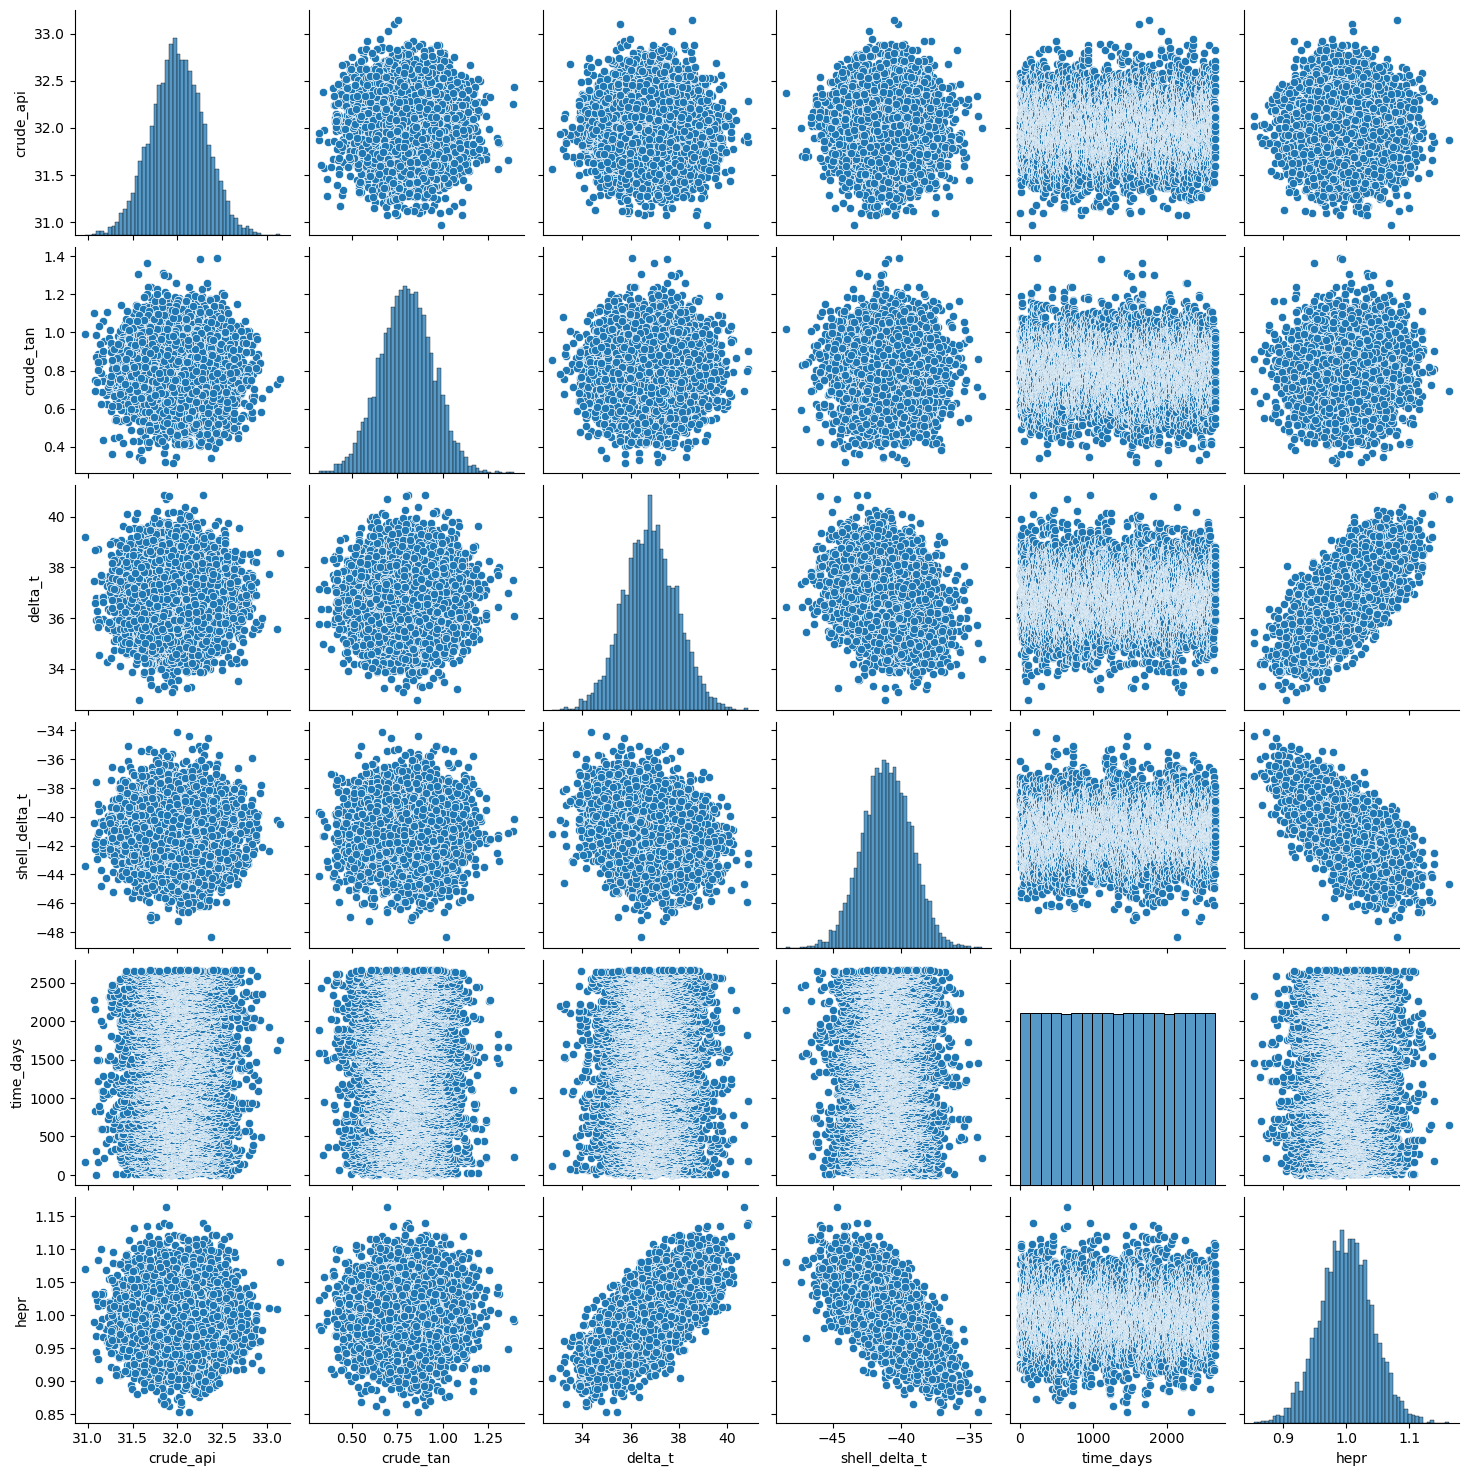

In [14]:
# Pairplot for a subset
subset_cols = ['crude_api', 'crude_tan', 'delta_t', 'shell_delta_t', 'time_days', 'hepr']
sns.pairplot(df[subset_cols])
plt.show()

In [15]:
#TRAIN–TEST SPLIT (HOLDOUT VALIDATION)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 80–20 split
    random_state=42       # important for reproducibility
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 5120
Testing samples : 1280


In [16]:
# DEFINE MLR MODEL

mlr_model = LinearRegression()   # fit_intercept=True by default


# TRAIN MLR MODEL

mlr_model.fit(X_train, y_train)
print("MLR model training completed.")

MLR model training completed.


In [17]:
print("Intercept (bias):", mlr_model.intercept_)
print("Coefficients (per feature):")
for name, coef in zip(X.columns, mlr_model.coef_):
    print(f"{name:35s} : {coef:.6f}")

Intercept (bias): -1.0015067502342503
Coefficients (per feature):
crude_api                           : 0.000046
crude_chlorides                     : -0.000001
crude_tan                           : -0.000029
time_hr                             : -0.000000
time_days                           : -0.000000
e03_crude_tube_t_in_degc            : -0.009050
e03_crude_tube_t_out_degc           : 0.009021
e03_crude_tube_m_kg_s               : 0.009965
e03_crude_tube_cp_j_kgk             : 0.000000
e03_lightdiesel_shell_t_in_degc     : 0.000018
e03_lightdiesel_shell_t_out_degc    : 0.000018
e03_lightdiesel_shell_m_kg_s        : 0.000016
delta_t                             : 0.018071
shell_delta_t                       : 0.000000


In [18]:
# PREDICTIONS (TRAIN & TEST)
y_train_pred_mlr = mlr_model.predict(X_train)
y_test_pred_mlr  = mlr_model.predict(X_test)

In [19]:
# METRICS FUNCTION 

def evaluate_model(y_true, y_pred, label="RESULTS"):
    r2  = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"\n--- {label} ---")
    print(f"R²   : {r2:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.4f}")
    return r2, mae, mse, rmse


# EVALUATE MLR

evaluate_model(y_train, y_train_pred_mlr, "TRAINING (MLR)")
evaluate_model(y_test,  y_test_pred_mlr,  "TESTING (MLR)")


--- TRAINING (MLR) ---
R²   : 0.9995
MAE   : 0.0006
MSE  : 0.000001
RMSE : 0.0010

--- TESTING (MLR) ---
R²   : 0.9995
MAE   : 0.0006
MSE  : 0.000001
RMSE : 0.0009


(0.9995243246568949,
 0.0005835503188140053,
 8.129951571105627e-07,
 np.float64(0.000901662440778456))

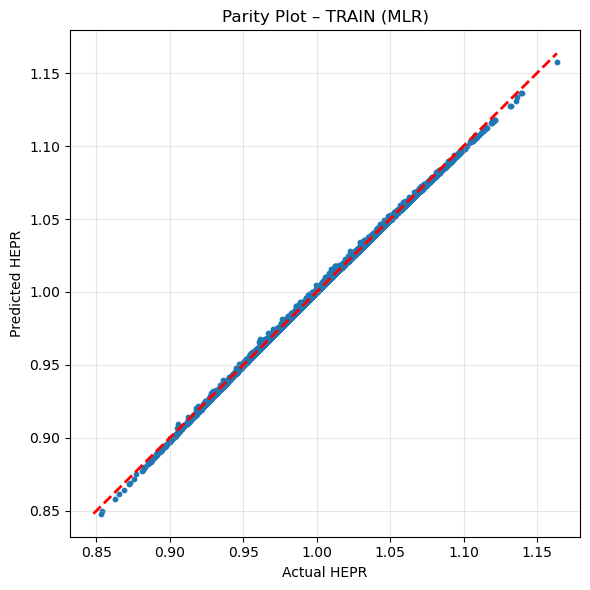

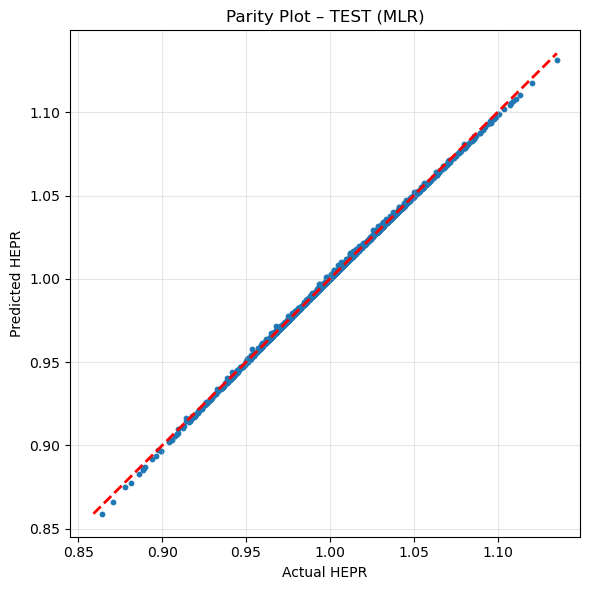

In [20]:
# PARITY PLOT FUNCTION (ACTUAL vs PREDICTED)

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    plt.xlabel("Actual HEPR")
    plt.ylabel("Predicted HEPR")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# PARITY PLOTS FOR MLR

parity_plot(y_train, y_train_pred_mlr, "Parity Plot – TRAIN (MLR)")
parity_plot(y_test,  y_test_pred_mlr,  "Parity Plot – TEST (MLR)")

In [21]:
# 5-FOLD CROSS VALIDATION (MLR)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R² across folds
cv_r2_mlr = cross_val_score(mlr_model, X, y, cv=kf, scoring='r2')

# RMSE across folds (using negative MSE)
cv_rmse_mlr = np.sqrt(
    -cross_val_score(mlr_model, X, y, cv=kf, scoring='neg_mean_squared_error')
)

print("\n========== 5-FOLD CROSS VALIDATION (MLR) ==========")
print("R² scores :", cv_r2_mlr)
print("Mean R²   :", cv_r2_mlr.mean(), "±", cv_r2_mlr.std())

print("\nRMSE scores:", cv_rmse_mlr)
print("Mean RMSE  :", cv_rmse_mlr.mean(), "±", cv_rmse_mlr.std())


========== 5-FOLD CROSS VALIDATION (MLR) ==========
R² scores : [0.99952432 0.9995001  0.99947841 0.99944617 0.9994845 ]
Mean R²   : 0.999486700540605 ± 2.5735502172294047e-05

RMSE scores: [0.00090166 0.00093433 0.00098879 0.00095322 0.00094566]
Mean RMSE  : 0.0009447316492159905 ± 2.8202080104895406e-05


In [22]:
# SVR MODEL WITH SCALING (PIPELINE)

svr_model = Pipeline([
    ("scaler", StandardScaler()),      # scales all features
    ("svr", SVR(kernel='rbf', C=10.0, epsilon=0.01))  # SVR with RBF kernel
])

In [23]:
# TRAIN THE SVR MODEL ON TRAINING DATA

svr_model.fit(X_train, y_train)
print("SVR model training completed.")

SVR model training completed.


In [24]:
# PREDICT ON TRAIN AND TEST SETS

y_train_pred = svr_model.predict(X_train)
y_test_pred  = svr_model.predict(X_test)

In [25]:
# FUNCTION TO COMPUTE METRICS

def evaluate_model(y_true, y_pred, label="RESULTS"):
    r2  = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"\n--- {label} ---")
    print(f"R²   : {r2:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.4f}")
    
    return r2, mae, mse, rmse

# Compute metrics for train and test
evaluate_model(y_train, y_train_pred, "TRAINING (SVR)")
evaluate_model(y_test,  y_test_pred,  "TESTING (SVR)")


--- TRAINING (SVR) ---
R²   : 0.9873
MAE   : 0.0038
MSE  : 0.000022
RMSE : 0.0047

--- TESTING (SVR) ---
R²   : 0.9825
MAE   : 0.0040
MSE  : 0.000030
RMSE : 0.0055


(0.982460322293879,
 0.003988429332035139,
 2.997774267480693e-05,
 np.float64(0.005475193391543985))

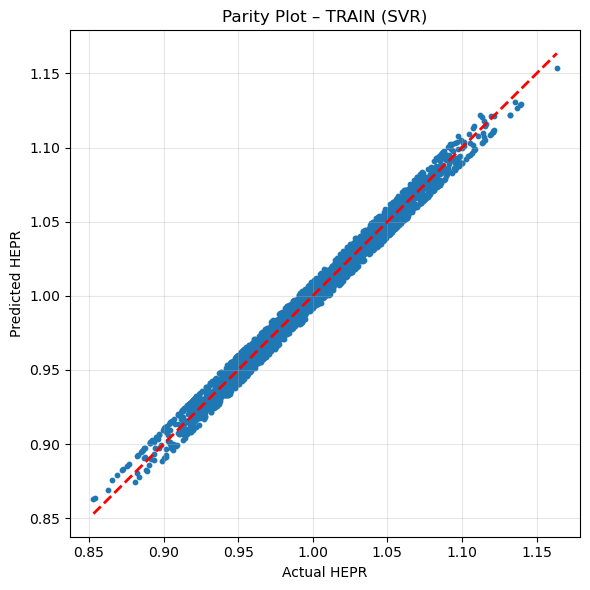

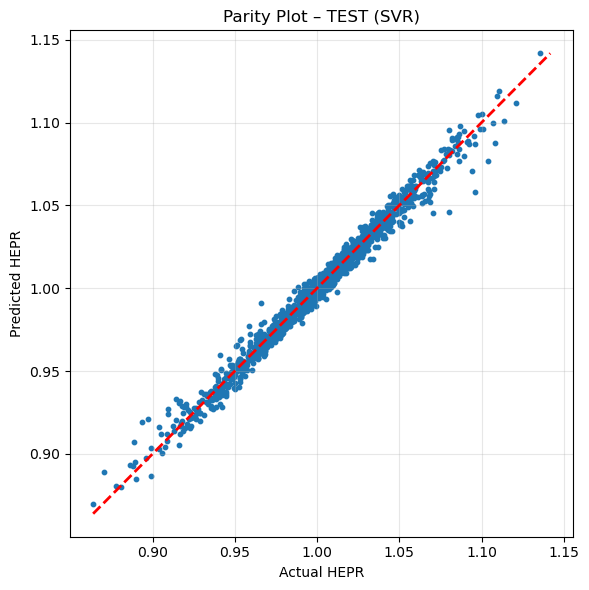

In [26]:
# PARITY PLOT FUNCTION (ACTUAL VS PREDICTED)

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10)
    
    # line y=x
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    plt.xlabel("Actual HEPR")
    plt.ylabel("Predicted HEPR")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Train and test parity plots
parity_plot(y_train, y_train_pred, "Parity Plot – TRAIN (SVR)")
parity_plot(y_test,  y_test_pred,  "Parity Plot – TEST (SVR)")

In [27]:
# 5-FOLD CROSS VALIDATION (R² and RMSE)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R² scores
cv_r2 = cross_val_score(svr_model, X, y, cv=kf, scoring='r2')

# RMSE scores (requires negative MSE)
cv_rmse = np.sqrt(-cross_val_score(svr_model, X, y, cv=kf, scoring='neg_mean_squared_error'))

print("\n========== 5-FOLD CROSS VALIDATION RESULTS ==========")
print("R² scores: ", cv_r2)
print("Mean R²   :", cv_r2.mean(), "±", cv_r2.std())

print("\nRMSE scores:", cv_rmse)
print("Mean RMSE :", cv_rmse.mean(), "±", cv_rmse.std())


========== 5-FOLD CROSS VALIDATION RESULTS ==========
R² scores:  [0.98246032 0.98037096 0.98051311 0.98169123 0.98045581]
Mean R²   : 0.9810982863892331 ± 0.000835575212715099

RMSE scores: [0.00547519 0.00585474 0.00604381 0.00548068 0.00582274]
Mean RMSE : 0.005735432918899199 ± 0.00022341562406540558


In [28]:
# PCA
#SCALE X (zero mean, unit variance)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)   # shape: (n_samples, n_features)

# FIT PCA WITH ALL COMPONENTS
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)   # PC scores

# Keep as DataFrame for easier labeling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("X_scaled shape:", X_scaled_df.shape)
X_scaled_df.head()

X_scaled shape: (6400, 14)


,crude_api,crude_chlorides,crude_tan,time_hr,time_days,e03_crude_tube_t_in_degc,e03_crude_tube_t_out_degc,e03_crude_tube_m_kg_s,e03_crude_tube_cp_j_kgk,e03_lightdiesel_shell_t_in_degc,e03_lightdiesel_shell_t_out_degc,e03_lightdiesel_shell_m_kg_s,delta_t,shell_delta_t
0,0.085259,0.090311,-0.216016,-1.731780,-1.731780,0.346708,0.441657,-0.577866,0.0,0.706149,0.412510,-0.598873,0.139747,-0.197925
1,-0.261598,-0.224950,-0.295768,-1.731239,-1.731239,1.526210,1.124264,-1.262265,0.0,-0.134677,1.006114,-0.570155,-0.676808,1.064715
2,0.171621,0.315776,-0.477539,-1.730698,-1.730698,1.190175,0.769741,-1.751657,0.0,-1.377303,0.930506,0.619395,-0.696377,2.028642
3,1.807398,-0.536757,0.575907,-1.730156,-1.730156,0.187053,-0.175140,-0.667207,0.0,-1.526270,-0.253031,0.719640,-0.576051,1.032328
4,0.023030,0.412540,-0.039504,-1.729615,-1.729615,0.259913,-0.109080,0.030136,0.0,-1.149215,0.185841,0.539876,-0.588838,1.133600


In [29]:
# PCA: COVARIANCE MATRIX & EIGEN-DECOMPOSITION

# Covariance matrix of scaled data (variables in rows/cols)
cov_mat = np.cov(X_scaled_df.T)        # shape: (p, p) where p = number of features
print("Covariance matrix shape:", cov_mat.shape)

# Eigenvalues & eigenvectors of covariance matrix
eig_vals, eig_vecs = np.linalg.eigh(cov_mat)   # eigh since cov_mat is symmetric

# Sort eigenvalues (and eigenvectors) in descending order
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

print("Eigenvalues (descending):")
print(eig_vals)

Covariance matrix shape: (14, 14)
Eigenvalues (descending):
[ 4.00225133e+00  2.16479297e+00  1.98713210e+00  1.28301768e+00
  1.02830811e+00  9.99145451e-01  9.57211590e-01  4.93749069e-01
  5.58521181e-02  3.05711529e-02  3.17023676e-16  8.15837697e-17
 -2.36442044e-17 -4.37185753e-17]


In [30]:
#EXPLAINED VARIANCE & CPV TABLE 

total_variance = eig_vals.sum()
explained_var_ratio = eig_vals / total_variance
cum_explained_var = np.cumsum(explained_var_ratio)

pca_summary = pd.DataFrame({
    "Eigenvalue": eig_vals,
    "Explained_Variance_Ratio": explained_var_ratio,
    "Cumulative_Explained_Variance": cum_explained_var
}, index=[f"PC{i+1}" for i in range(len(eig_vals))])

print("PCA summary (eigenvalues, explained variance, CPV):")
pca_summary

# Explained variance ratio of each component
explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

PCA summary (eigenvalues, explained variance, CPV):


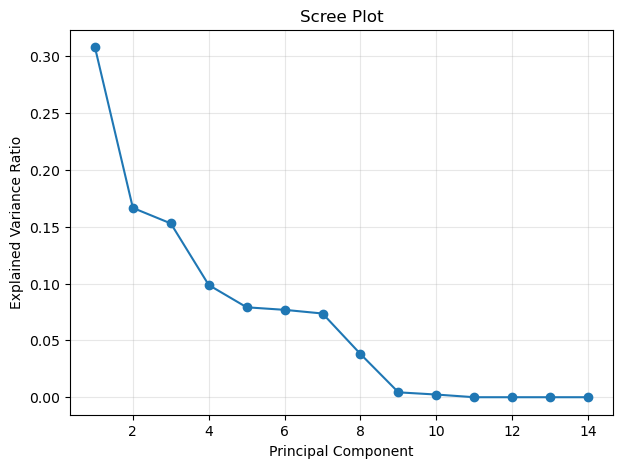

In [31]:
# SCREE PLOT (VARIANCE PER COMPONENT)

plt.figure(figsize=(7,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(alpha=0.3)
plt.show()

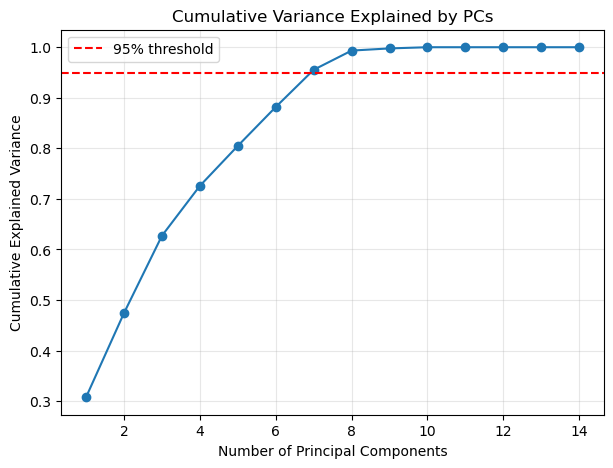

Number of PCs needed to retain ≥95% variance: 7


In [32]:
#CUMULATIVE VARIANCE PLOT

plt.figure(figsize=(7,5))
plt.plot(range(1, len(cum_explained_var)+1), cum_explained_var, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCs")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Decide number of PCs to retain (e.g. 95% variance)
n_pcs_95 = np.argmax(cum_explained_var >= 0.95) + 1
print("Number of PCs needed to retain ≥95% variance:", n_pcs_95)

In [33]:
# LOADINGS (CONTRIBUTION OF ORIGINAL FEATURES)

# Each column of eig_vecs is a loading vector for one PC
loadings = eig_vecs   # shape: (p_features, p_components)

loadings_df = pd.DataFrame(
    loadings,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(loadings.shape[1])]
)

print("Loadings (first few PCs):")
loadings_df.iloc[:, :7]   # show first 7 PCs

Loadings (first few PCs):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
crude_api,-0.022903,3.003334e-02,2.741954e-02,2.491654e-02,-7.247688e-01,-2.185193e-01,-6.511784e-01
crude_chlorides,0.011128,-5.214894e-03,1.689996e-02,-9.017466e-02,6.640676e-01,-4.463133e-01,-5.924649e-01
crude_tan,0.017093,-4.835848e-02,1.426072e-02,-1.401802e-01,1.477444e-01,8.617917e-01,-4.613706e-01
time_hr,0.013820,2.022596e-01,6.766934e-01,9.178372e-03,1.153518e-02,1.100680e-02,2.137696e-02
time_days,0.013820,2.022596e-01,6.766934e-01,9.178372e-03,1.153518e-02,1.100680e-02,2.137696e-02
e03_crude_tube_t_in_degc,0.426612,2.244136e-01,-8.583416e-02,2.615103e-01,2.131484e-02,3.431557e-02,-3.080556e-02
e03_crude_tube_t_out_degc,0.476246,-1.463149e-01,3.125203e-02,1.573603e-01,-2.756222e-03,2.453091e-03,-1.648212e-02
e03_crude_tube_m_kg_s,-0.412733,-9.790997e-02,2.479939e-02,-1.922080e-01,-1.332806e-02,-1.958413e-03,2.960838e-02
e03_crude_tube_cp_j_kgk,0.000000,-4.336809e-19,8.673617e-19,-2.775558e-17,-5.551115e-17,2.220446e-16,-4.163336e-17
e03_lightdiesel_shell_t_in_degc,0.071430,-5.653181e-01,1.566449e-01,3.759881e-01,1.920771e-02,1.082388e-02,-2.589564e-02


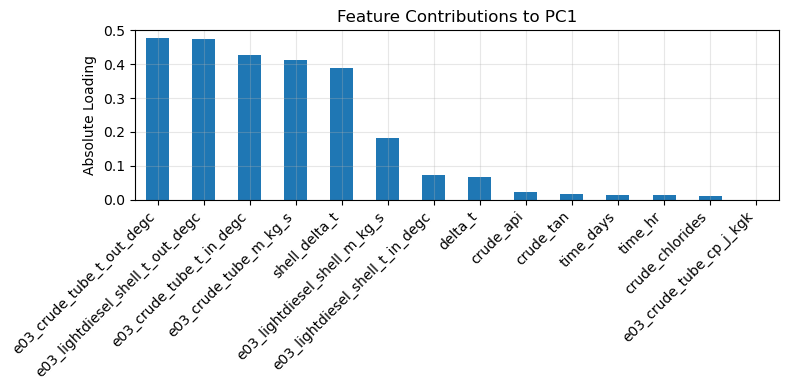

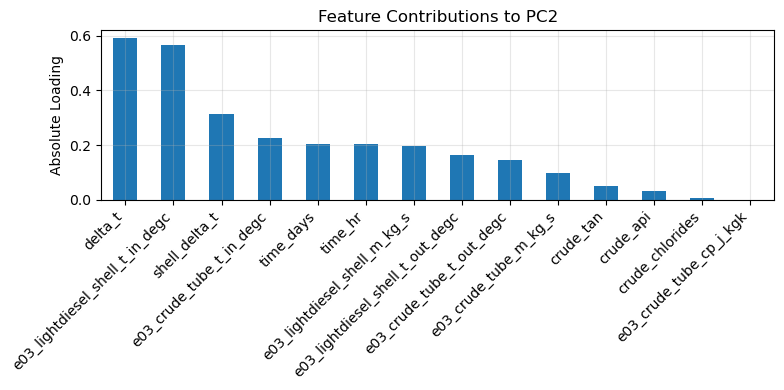

In [34]:
# FEATURE CONTRIBUTION BAR PLOTS

# Example: absolute loadings for PC1 and PC2
for pc in ["PC1", "PC2"]:
    plt.figure(figsize=(8, 4))
    loadings_df[pc].abs().sort_values(ascending=False).plot(kind='bar')
    plt.ylabel("Absolute Loading")
    plt.title(f"Feature Contributions to {pc}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.grid(alpha=0.3)
    plt.show()


In [35]:
# PCA: SCORE COMPUTATION (PC SCORES) 

# Scores = X_scaled * eigenvectors  (projection of data onto PCs)
# Use first d PCs (e.g. n_pcs_95 from above)
d = n_pcs_95        # or set manually, e.g. d = 2 or d = 3
print("Using d =", d, "principal components for scores.")

scores = X_scaled_df.values @ eig_vecs[:, :d]   # shape: (n_samples, d)

scores_df = pd.DataFrame(
    scores,
    columns=[f"PC{i+1}" for i in range(d)]
)

scores_df.head()


Using d = 7 principal components for scores.


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,0.613528,-1.112413,-2.239642,1.009149,-0.001102,-0.225701,-0.184418
1,2.392208,0.366952,-2.736415,0.952693,0.018237,-0.040889,0.248848
2,2.741149,1.206784,-2.933219,-0.782964,-0.121589,-0.666216,-0.108869
3,0.452496,0.890768,-2.742788,-1.222159,-1.708391,0.250100,-1.106066
4,0.509210,0.590066,-2.719455,-1.136553,0.127376,-0.303238,-0.222094


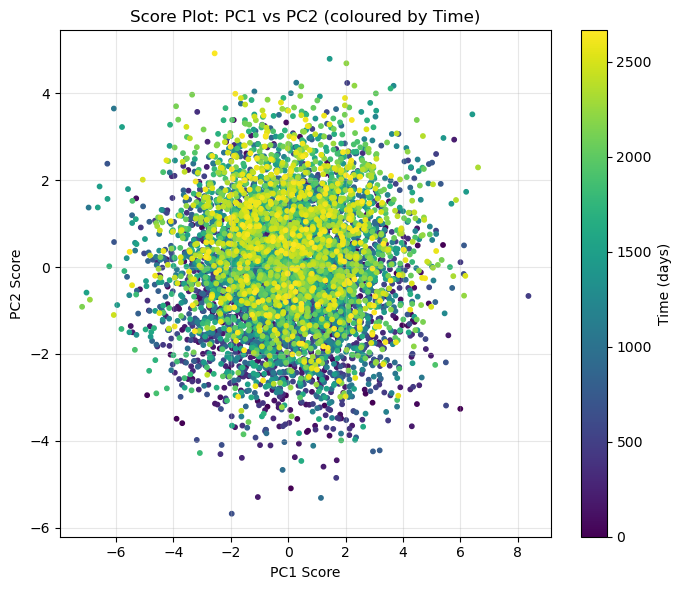

In [36]:
#PCA: 2D SCORE PLOT (PC1 vs PC2)

if d >= 2:
    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        scores_df["PC1"],
        scores_df["PC2"],
        c=df["time_days"],   # color by operating time (or any other variable)
        cmap="viridis",
        s=10
    )
    plt.colorbar(scatter, label="Time (days)")
    plt.xlabel("PC1 Score")
    plt.ylabel("PC2 Score")
    plt.title("Score Plot: PC1 vs PC2 (coloured by Time)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [37]:
#PCR
# Choose number of PCs 
n_components_pcr = n_pcs_95   

print("Using", n_components_pcr, "principal components in PCR.")


# DEFINE PIPELINE

pcr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components_pcr)),
    ("linreg", LinearRegression())
])

Using 7 principal components in PCR.


In [38]:
#TRAIN PCR MODEL

pcr_model.fit(X_train, y_train)
print("PCR model training completed.")

PCR model training completed.


In [39]:
#EVALUATE ON TRAIN & TEST

def evaluate_model(y_true, y_pred, label="RESULTS"):
    r2  = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"\n--- {label} ---")
    print(f"R²   : {r2:.4f}")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.4f}")
    return r2, mse, rmse

y_train_pred_pcr = pcr_model.predict(X_train)
y_test_pred_pcr  = pcr_model.predict(X_test)

evaluate_model(y_train, y_train_pred_pcr, "TRAINING (PCR)")
evaluate_model(y_test,  y_test_pred_pcr,  "TESTING (PCR)")


--- TRAINING (PCR) ---
R²   : 0.9558
MSE  : 0.000077
RMSE : 0.0088

--- TESTING (PCR) ---
R²   : 0.9547
MSE  : 0.000077
RMSE : 0.0088


(0.9546777662951366, 7.746198546041195e-05, np.float64(0.008801249085238523))

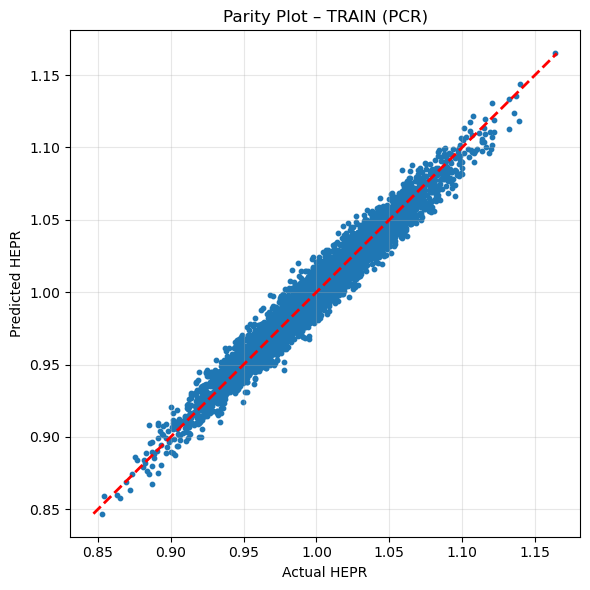

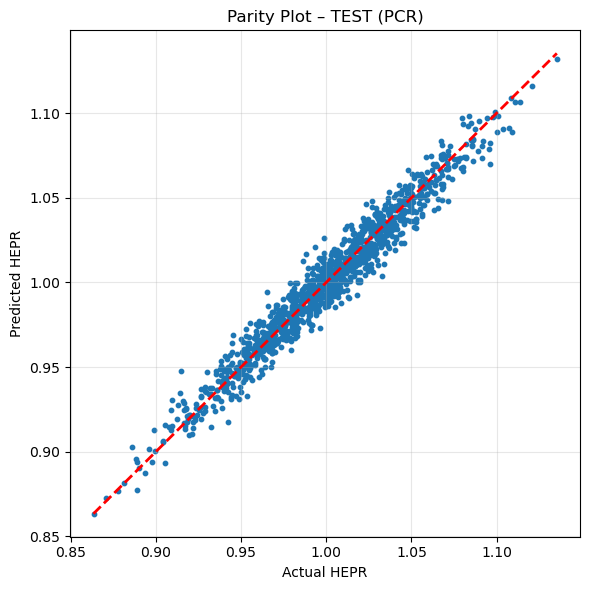

In [40]:
#PARITY PLOTS (TRAIN & TEST)

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=10)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    plt.xlabel("Actual HEPR")
    plt.ylabel("Predicted HEPR")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

parity_plot(y_train, y_train_pred_pcr, "Parity Plot – TRAIN (PCR)")
parity_plot(y_test,  y_test_pred_pcr,  "Parity Plot – TEST (PCR)")

In [41]:
#5-FOLD CROSS VALIDATION

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R² scores
cv_r2_pcr = cross_val_score(pcr_model, X, y, cv=kf, scoring='r2')

# RMSE scores
cv_rmse_pcr = np.sqrt(
    -cross_val_score(pcr_model, X, y, cv=kf, scoring='neg_mean_squared_error')
)

print("\n========== 5-FOLD CROSS VALIDATION (PCR) ==========")
print("R² scores :", cv_r2_pcr)
print("Mean R²   :", cv_r2_pcr.mean(), "±", cv_r2_pcr.std())

print("\nRMSE scores:", cv_rmse_pcr)
print("Mean RMSE  :", cv_rmse_pcr.mean(), "±", cv_rmse_pcr.std())


========== 5-FOLD CROSS VALIDATION (PCR) ==========
R² scores : [0.95467777 0.95668615 0.95767435 0.95377738 0.95534974]
Mean R²   : 0.9556330762793716 ± 0.0013937205509186267

RMSE scores: [0.00880125 0.00869705 0.0089072  0.00870828 0.00880097]
Mean RMSE  : 0.008782948065554871 ± 7.622567324562057e-05
